# DreamLens unified feature visualization — native PyTorch

This notebook uses one root API, `dreamlens.FeatureVisualizer`, for all three workflows:

1. **Classical maximize** — optimize an FFT canvas for a layer, channel, flattened neuron, class logit, or activation direction.
2. **MaCo** — keep a natural-image Fourier magnitude fixed and optimize only phase, returning both an image and an importance map.
3. **Caricature** — amplify the features already present in a real image.

Everything runs directly in notebook cells through normal package imports. There is no runner script, TensorFlow, Keras, Xplique dependency, or Hugging Face model. The example uses a pretrained **torchvision ResNet18**.

MaCo follows Fel et al., [*Unlocking Feature Visualization for Deeper Networks with MAgnitude Constrained Optimization*](https://arxiv.org/abs/2306.06805).

In [1]:
from pathlib import Path
import random
import time

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import torch
import torch.nn.functional as F
from torchvision.models import ResNet18_Weights, resnet18

from dreamlens import (
    AmplifyConfig,
    FeatureTarget,
    FeatureVisualizer,
    MacoConfig,
    RenderConfig,
    TransformConfig,
)

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "examples" else Path.cwd()
OUTPUT_DIR = REPO_ROOT / "results" / "feature_visualization_getting_started_pytorch"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SEED = 17

def set_seed(value):
    random.seed(value)
    np.random.seed(value)
    torch.manual_seed(value)

set_seed(SEED)
torch.set_num_threads(min(11, torch.get_num_threads()))
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", DEVICE)
print("output directory:", OUTPUT_DIR)

device: cpu
output directory: /Users/susmered/Documents/arena/activation-atlas-pytorch/results/feature_visualization_getting_started_pytorch


## 1. Editable parameters

This is the main cell to edit. `TARGET_KIND` accepts `"layer"`, `"channel"`, `"neuron"`, `"class"`, or `"direction"`.

- A **channel** selects one channel and reduces its spatial/token positions.
- A **neuron** selects one flattened scalar from any layer output.
- A **class** is a neuron in the classifier output; here class 96 is ImageNet Toucan.
- A **direction** is a complete tensor/vector in a layer's activation space.

`RenderConfig`, `MacoConfig`, and `AmplifyConfig` expose the algorithm-specific parameters without changing the API object.

In [2]:
# Shared target settings
TARGET_KIND = "class"       # layer | channel | neuron | class | direction
TARGET_LAYER = "fc"
TARGET_INDEX = 96            # ImageNet class 96: Toucan
TARGET_REDUCTION = "mean"    # mean | sum | max | norm
TARGET_WEIGHT = 1.0
TARGET_SIGN = 1.0            # +1 maximize, -1 suppress
DIRECTION_COSSIM_POWER = 2.0

# Classical maximize settings
RUN_MAXIMIZE = True
MAXIMIZE_SIZE = 224
MAXIMIZE_STEPS = 160
MAXIMIZE_LR = 1.2e-2

# MaCo settings
RUN_MACO = True
MACO_SIZE = 512
MACO_STEPS = 128
MACO_CROPS = 8
MACO_LR = 1.0
MACO_NOISE = 0.08
USE_BUILTIN_MACO_SPECTRUM = False  # True uses/downloads the official ImageNet spectrum
MACO_MAGNITUDE_IMAGE = REPO_ROOT / "learning_inputs" / "torchvision_dog.jpg"

# Caricature settings
RUN_CARICATURE = True
CARICATURE_INPUT = REPO_ROOT / "learning_inputs" / "dog_160.png"
CARICATURE_LAYER = "layer3.1.conv2"
CARICATURE_SIZE = 224
CARICATURE_STEPS = 200
CARICATURE_LR = 9e-3
CARICATURE_POWER = 1.20

## 2. Torchvision model and differentiable preprocessing

The optimizer changes pixels, not model weights. ImageNet normalization is applied immediately before model inference so every workflow uses torchvision's expected input distribution.

In [3]:
weights = ResNet18_Weights.DEFAULT
model = resnet18(weights=weights).to(DEVICE).eval()
for parameter in model.parameters():
    parameter.requires_grad_(False)

IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)

def imagenet_preprocess(images):
    mean = images.new_tensor(IMAGENET_MEAN).view(1, 3, 1, 1)
    std = images.new_tensor(IMAGENET_STD).view(1, 3, 1, 1)
    return (images - mean) / std

visualizer = FeatureVisualizer(
    model,
    device=DEVICE,
    preprocess=imagenet_preprocess,
    quiet=True,
)
print("model:", model.__class__.__name__)
print("class:", TARGET_INDEX, weights.meta["categories"][TARGET_INDEX])

model: ResNet
class: 96 toucan


## 3. One target object for every method

The same `FeatureTarget` can be passed to `method="maximize"` or `method="maco"`. This keeps target selection and reduction identical across algorithms.

In [4]:
def make_target(kind, layer, index=None):
    common = dict(
        layer=layer,
        weight=TARGET_WEIGHT,
        sign=TARGET_SIGN,
        reduction=TARGET_REDUCTION,
    )
    if kind == "layer":
        return FeatureTarget(**common)
    if kind == "channel":
        return FeatureTarget(**common, channel=index)
    if kind in {"neuron", "class"}:
        return FeatureTarget(**common, neuron=index)
    if kind == "direction":
        if layer != "fc":
            raise ValueError("Edit direction_tensor to match the selected layer output")
        direction_tensor = F.one_hot(torch.tensor(index), num_classes=1000).float()
        return FeatureTarget(
            **common,
            direction=direction_tensor,
            cossim_power=DIRECTION_COSSIM_POWER,
        )
    raise ValueError("TARGET_KIND must be layer, channel, neuron, class, or direction")

target = make_target(TARGET_KIND, TARGET_LAYER, TARGET_INDEX)
print(target)
print("Conveniences: maximize_layer / maximize_channel / maximize_neuron /")
print("              maximize_class / maximize_direction")

FeatureTarget(layer='fc', channel=None, neuron=96, position=None, direction=None, reduction='mean', weight=1.0, sign=1.0, cossim_power=2.0)
Conveniences: maximize_layer / maximize_channel / maximize_neuron /
              maximize_class / maximize_direction


## 4. Classical maximize

This uses DreamLens's Lucid-style FFT parameterization. The complete complex Fourier representation is trainable, so both magnitude and phase can change. Robust transforms make the target survive small rotations, scales, and translations.

finished in 3.5s
final minimization loss: -102.13481903076172
saved: /Users/susmered/Documents/arena/activation-atlas-pytorch/results/feature_visualization_getting_started_pytorch/root_maximize_toucan_224.png


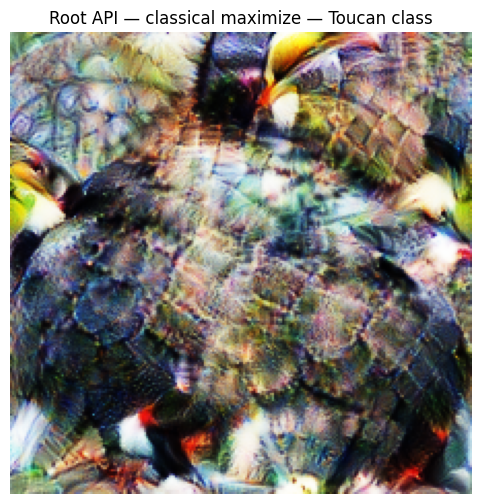

In [5]:
maximize_result = None
if RUN_MAXIMIZE:
    set_seed(SEED)
    maximize_config = RenderConfig.reference(
        width=MAXIMIZE_SIZE,
        height=MAXIMIZE_SIZE,
        steps=MAXIMIZE_STEPS,
        lr=MAXIMIZE_LR,
        transform=TransformConfig(
            rotate_degrees=6,
            scale_min=0.82,
            scale_max=1.12,
            translate_x=0.01,
            translate_y=0.01,
        ),
    )
    started = time.perf_counter()
    maximize_result = visualizer.visualize(
        target,
        method="maximize",
        config=maximize_config,
    )
    maximize_path = OUTPUT_DIR / "root_maximize_toucan_224.png"
    maximize_result.save(maximize_path)
    print(f"finished in {time.perf_counter() - started:.1f}s")
    print("final minimization loss:", maximize_result.objective_value)
    print("saved:", maximize_path)

    plt.figure(figsize=(6, 6))
    plt.imshow(maximize_result.as_hwc().clamp(0, 1))
    plt.title("Root API — classical maximize — Toucan class")
    plt.axis("off")
    plt.show()

## 5. MaCo through the same root API

MaCo reconstructs the image as $M_{natural}e^{i\phi}$. The natural-image magnitude $M_{natural}$ is fixed and only phase $\phi$ is optimized. `result.transparency` contains the accumulated absolute input gradient from the MaCo paper.

This checked-in run computes a fixed magnitude from the checked-in high-resolution [PyTorch Hub dog photograph](https://github.com/pytorch/hub/blob/master/images/dog.jpg), so it is fully reproducible offline. Set `USE_BUILTIN_MACO_SPECTRUM=True` to use/download the official ImageNet magnitude instead. Any representative iterable of NCHW batches can be supplied for another image domain.

finished in 16.1s
fixed magnitude source: /Users/susmered/Documents/arena/activation-atlas-pytorch/learning_inputs/torchvision_dog.jpg
image shape: (3, 512, 512)
importance shape: (3, 512, 512)
saved: /Users/susmered/Documents/arena/activation-atlas-pytorch/results/feature_visualization_getting_started_pytorch/root_maco_toucan_512.png
saved: /Users/susmered/Documents/arena/activation-atlas-pytorch/results/feature_visualization_getting_started_pytorch/root_maco_toucan_importance_512.png


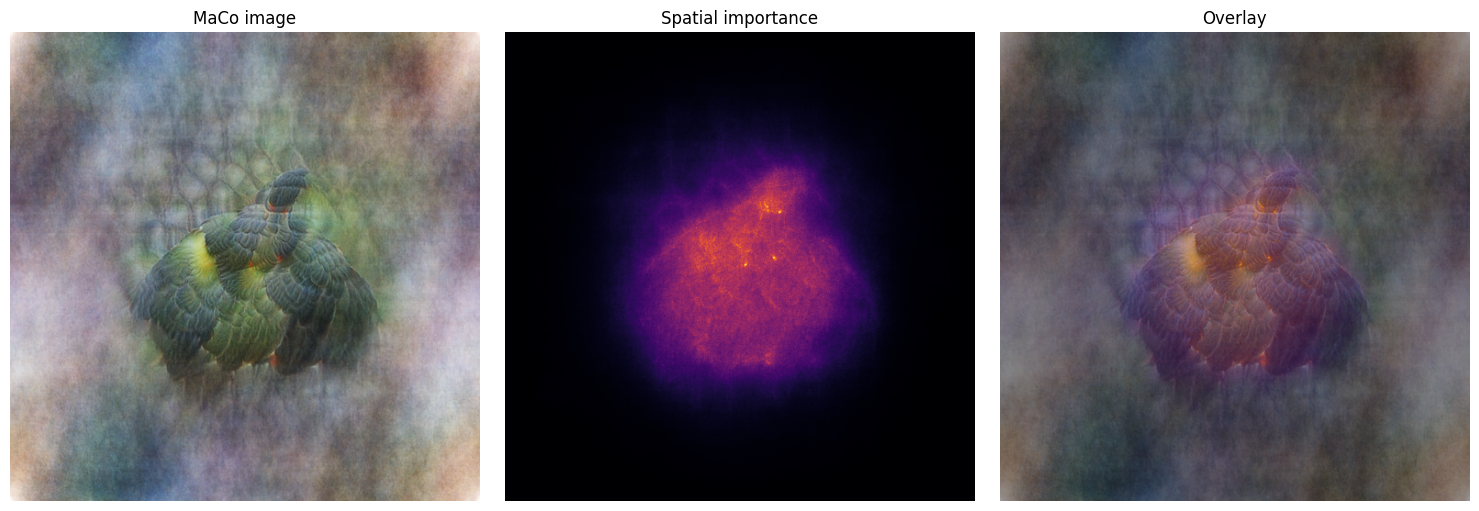

saved: /Users/susmered/Documents/arena/activation-atlas-pytorch/results/feature_visualization_getting_started_pytorch/root_maco_toucan_panel.png


In [6]:
maco_result = None
if RUN_MACO:
    set_seed(SEED)
    maco_config = MacoConfig(
        width=MACO_SIZE,
        height=MACO_SIZE,
        input_shape=(3, 224, 224),
        steps=MACO_STEPS,
        lr=MACO_LR,
        crops=MACO_CROPS,
        noise_intensity=MACO_NOISE,
        box_size=None,
        values_range=(0.0, 1.0),
    )

    # MaCo accepts a representative NCHW iterable for a domain-specific fixed
    # magnitude. None selects the official cached/downloaded ImageNet spectrum.
    if USE_BUILTIN_MACO_SPECTRUM:
        maco_dataset = None
        magnitude_source = "official ImageNet spectrum"
    else:
        spectrum_image = Image.open(MACO_MAGNITUDE_IMAGE).convert("RGB").resize(
            (MACO_SIZE, MACO_SIZE), Image.Resampling.LANCZOS
        )
        spectrum_array = np.asarray(spectrum_image, dtype=np.float32).copy() / 255.0
        spectrum_tensor = torch.from_numpy(spectrum_array).permute(2, 0, 1)
        maco_dataset = [torch.stack([
            spectrum_tensor,
            torch.flip(spectrum_tensor, dims=(-1,)),
            torch.flip(spectrum_tensor, dims=(-2,)),
        ])]
        magnitude_source = str(MACO_MAGNITUDE_IMAGE)

    started = time.perf_counter()
    maco_result = visualizer.visualize(
        target,
        method="maco",
        config=maco_config,
        maco_dataset=maco_dataset,
    )
    maco_path = OUTPUT_DIR / "root_maco_toucan_512.png"
    importance_path = OUTPUT_DIR / "root_maco_toucan_importance_512.png"
    maco_result.save(maco_path)
    maco_result.save_transparency(importance_path)

    importance = maco_result.transparency_chw().abs().mean(dim=0)
    importance = importance - importance.amin()
    importance = importance / importance.amax().clamp_min(1e-12)
    print(f"finished in {time.perf_counter() - started:.1f}s")
    print("fixed magnitude source:", magnitude_source)
    print("image shape:", tuple(maco_result.as_chw().shape))
    print("importance shape:", tuple(maco_result.transparency_chw().shape))
    print("saved:", maco_path)
    print("saved:", importance_path)

    figure, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(maco_result.as_hwc().clamp(0, 1))
    axes[0].set_title("MaCo image")
    axes[1].imshow(importance, cmap="inferno")
    axes[1].set_title("Spatial importance")
    axes[2].imshow(maco_result.as_hwc().clamp(0, 1))
    axes[2].imshow(importance, cmap="inferno", alpha=0.40)
    axes[2].set_title("Overlay")
    for axis in axes:
        axis.axis("off")
    figure.tight_layout()
    maco_panel_path = OUTPUT_DIR / "root_maco_toucan_panel.png"
    figure.savefig(maco_panel_path, dpi=140, bbox_inches="tight")
    plt.show()
    print("saved:", maco_panel_path)

## 6. Caricature from a real image

Caricature is not MaCo. It captures the selected layer's response to an input image, then creates a separate image pointing in the same activation direction with greater magnitude.

finished in 5.2s
final minimization loss: -7590139.0
saved: /Users/susmered/Documents/arena/activation-atlas-pytorch/results/feature_visualization_getting_started_pytorch/root_caricature_dog_224.png


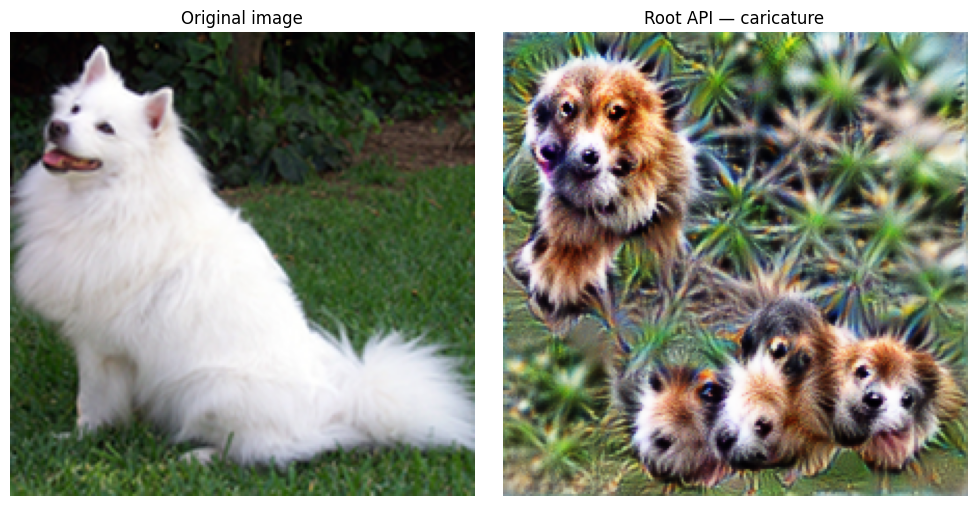

saved: /Users/susmered/Documents/arena/activation-atlas-pytorch/results/feature_visualization_getting_started_pytorch/root_caricature_dog_panel.png


In [7]:
caricature_result = None
if RUN_CARICATURE:
    input_image = Image.open(CARICATURE_INPUT).convert("RGB").resize(
        (CARICATURE_SIZE, CARICATURE_SIZE),
        Image.Resampling.LANCZOS,
    )
    set_seed(SEED + 100)
    caricature_config = AmplifyConfig.reference(
        steps=CARICATURE_STEPS,
        lr=CARICATURE_LR,
    )
    started = time.perf_counter()
    caricature_result = visualizer.visualize(
        method="caricature",
        image=input_image,
        layers=[CARICATURE_LAYER],
        power=CARICATURE_POWER,
        config=caricature_config,
    )
    caricature_path = OUTPUT_DIR / "root_caricature_dog_224.png"
    caricature_result.save(caricature_path)
    print(f"finished in {time.perf_counter() - started:.1f}s")
    print("final minimization loss:", caricature_result.objective_value)
    print("saved:", caricature_path)

    figure, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(input_image)
    axes[0].set_title("Original image")
    axes[1].imshow(caricature_result.as_hwc().clamp(0, 1))
    axes[1].set_title("Root API — caricature")
    for axis in axes:
        axis.axis("off")
    figure.tight_layout()
    caricature_panel_path = OUTPUT_DIR / "root_caricature_dog_panel.png"
    figure.savefig(caricature_panel_path, dpi=140, bbox_inches="tight")
    plt.show()
    print("saved:", caricature_panel_path)

## 7. Clean class-logit verification

This evaluates a clean, untransformed 224×224 model input separately from the stochastic optimization views.

In [8]:
def class_logit(result, class_id):
    image = result.as_nchw(device=DEVICE).clamp(0, 1)
    image = F.interpolate(image, size=(224, 224), mode="bilinear", align_corners=False)
    with torch.no_grad():
        return float(model(imagenet_preprocess(image))[0, class_id].cpu())

if maximize_result is not None:
    print("classical maximize Toucan logit:", class_logit(maximize_result, TARGET_INDEX))
if maco_result is not None:
    print("MaCo Toucan logit:", class_logit(maco_result, TARGET_INDEX))

classical maximize Toucan logit: 119.32825469970703
MaCo Toucan logit: 6.819263935089111


## Root API summary

```python
# One target definition
target = FeatureTarget(layer="fc", neuron=96)

# Classical FFT visualization
maximize_result = visualizer.visualize(target, "maximize", RenderConfig(...))

# Fixed-magnitude, phase-only MaCo
maco_result = visualizer.visualize(target, "maco", MacoConfig(...))

# Feature amplification from an existing image
caricature_result = visualizer.visualize(
    method="caricature", image=image, layers=["layer3.1.conv2"],
    config=AmplifyConfig(...),
)
```

Specialized `maximize_layer`, `maximize_channel`, `maximize_neuron`, `maximize_class`, and `maximize_direction` methods are conveniences over the same root target implementation. Batched forms are available as `maximize_channels`, `maximize_neurons`, `maximize_classes`, and `maximize_directions`.